
# Data Mining Assignment 3 – Clustering and Anomaly Detection
## Task 2: Clustering

---
### 0. Import & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os 
import json
import re
import scipy.sparse
import pickle

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import SpectralClustering

# paths creation need to adapt with yours
path = r'C:\Users\ephts\OneDrive\Documents\Master UA\Data mining\A3' 

data_path = os.path.join(path, 'datas')
preprocessed = os.path.join(path, 'preprocessed')
figures = os.path.join(path, 'fig')


print('Imported and paths created')


Imported and paths created


---
### 1. Load preprocessed data

In [2]:
X = scipy.sparse.load_npz(os.path.join(preprocessed, 'tfidf_matrix.npz'))

with open(os.path.join(preprocessed, 'vectorizer.pkl'), 'rb') as f:
    vectorizer = pickle.load(f)

article = pd.read_csv(os.path.join(preprocessed, 'article_clean.csv'))
feature_names = vectorizer.get_feature_names_out()

print(f"Matrix loaded: {X.shape}")
print(f"Articles loaded: {len(article)}")

Matrix loaded: (2164, 5000)
Articles loaded: 2164


---
### 2. Dimensionality reduction - LSA

In [3]:
svd = TruncatedSVD(n_components=100, random_state=42)
X_lsa = svd.fit_transform(X)

# Normalize (important for cosine similarity)
X_lsa = normalize(X_lsa, norm='l2')

print(f"Original shape : {X.shape}")
print(f"Reduced shape  : {X_lsa.shape}")
print(f"Variance explained: {svd.explained_variance_ratio_.sum():.2%}")

Original shape : (2164, 5000)
Reduced shape  : (2164, 100)
Variance explained: 21.23%


In [4]:
# Try different numbers of components
for n in [50, 100, 200, 300]:
    svd_test = TruncatedSVD(n_components=n, random_state=42)
    svd_test.fit(X)
    print(f"  {n} components → {svd_test.explained_variance_ratio_.sum():.2%} variance explained")

  50 components → 13.68% variance explained
  100 components → 21.23% variance explained
  200 components → 33.33% variance explained
  300 components → 43.16% variance explained


In [22]:
# Final LSA with 200 components
svd = TruncatedSVD(n_components=200, random_state=42)
X_lsa = svd.fit_transform(X)
X_lsa = normalize(X_lsa, norm='l2')

print(f"Final reduced shape : {X_lsa.shape}")

Final reduced shape : (2164, 200)


---
### 3. Choosing K - Elbow Silhouette

K=2 | inertia=2,034 | silhouette=0.0178
K=3 | inertia=1,981 | silhouette=0.0331
K=4 | inertia=1,959 | silhouette=0.0344
K=5 | inertia=1,929 | silhouette=0.0444
K=6 | inertia=1,908 | silhouette=0.0471
K=7 | inertia=1,891 | silhouette=0.0489
K=8 | inertia=1,879 | silhouette=0.0504
K=9 | inertia=1,869 | silhouette=0.0478
K=10 | inertia=1,859 | silhouette=0.0480


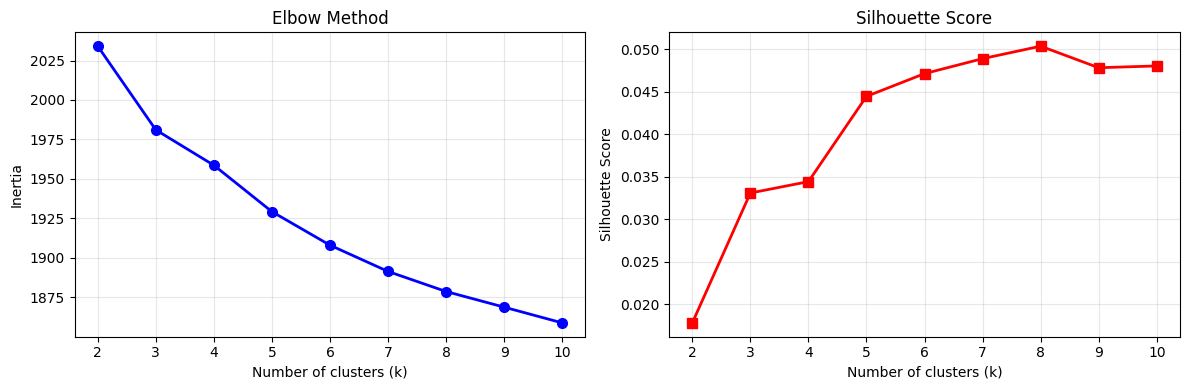


Best K according to silhouette: 8

Cluster sizes:
cluster_kmeans
0    560
1    366
2    255
3    237
4    333
5     50
6    293
7     70
Name: count, dtype: int64


In [23]:
k_values = range(2, 11)
inertias = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_lsa)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_lsa, labels))
    print(f"K={k} | inertia={km.inertia_:,.0f} | silhouette={sil_scores[-1]:.4f}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(k_values, inertias, 'bo-', linewidth=2, markersize=7)
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(alpha=0.3)

ax2.plot(k_values, sil_scores, 'rs-', linewidth=2, markersize=7)
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(figures, 'elbow_silhouette.png'), dpi=150)
plt.show()

# Best K
best_k = k_values[np.argmax(sil_scores)]
print(f"\nBest K according to silhouette: {best_k}")

# Final KMeans
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_km = kmeans_final.fit_predict(X_lsa)
article['cluster_kmeans'] = labels_km

print("\nCluster sizes:")
print(article['cluster_kmeans'].value_counts().sort_index())

---
### 4. Top words per cluster

In [24]:
def top_terms_per_cluster(X_tfidf, labels, feature_names, n=10):
    for c in sorted(set(labels)):
        mask = labels == c
        cluster_mean = np.asarray(X_tfidf[mask].mean(axis=0)).flatten()
        top_idx = cluster_mean.argsort()[-n:][::-1]
        top = list(feature_names[top_idx])
        print(f"Cluster {c} ({mask.sum()} docs): {top}")

print("=== K-Means Top Terms per Cluster ===\n")
top_terms_per_cluster(X, labels_km, feature_names)

=== K-Means Top Terms per Cluster ===

Cluster 0 (560 docs): ['people', 'time', 'right', 'good', 'new', 'make', 'does', 'did', 'way', 'sure']
Cluster 1 (366 docs): ['game', 'team', 'hockey', 'play', 'players', 'games', 'season', 'nhl', 'teams', 'year']
Cluster 2 (255 docs): ['car', 'cars', 'engine', 'dealer', 'price', 'good', 'speed', 'drive', 'new', 'ford']
Cluster 3 (237 docs): ['space', 'orbit', 'moon', 'launch', 'earth', 'lunar', 'nasa', 'shuttle', 'station', 'cost']
Cluster 4 (333 docs): ['thanks', 'graphics', 'files', 'program', 'image', 'file', 'does', 'help', 'windows', 'looking']
Cluster 5 (50 docs): ['ref', 'sale', 'promo', 'id', 'listing', 'code', 'pickup', 'bonus', 'listing id', 'offer']
Cluster 6 (293 docs): ['msg', 'disease', 'food', 'doctor', 'people', 'cause', 'pain', 'medical', 'treatment', 'patients']
Cluster 7 (70 docs): ['surrender soon', 'intellect shameful', 'shameful', 'shameful surrender', 'chastity intellect', 'skepticism chastity', 'banks jxp', 'chastity', 'jx

---
### 5. Name the clusters

In [25]:
cluster_names = {
    0: 'General/Discussion',
    1: 'Hockey/Sport',
    2: 'Cars',
    3: 'Space/NASA',
    4: 'Computing',
    5: 'Marketplace/Listings',
    6: 'Medicine/Health',
    7: 'Repetitive/Unusual Text',
}

article['cluster_name'] = article['cluster_kmeans'].map(cluster_names)
print(article['cluster_name'].value_counts())

cluster_name
General/Discussion         560
Hockey/Sport               366
Computing                  333
Medicine/Health            293
Cars                       255
Space/NASA                 237
Repetitive/Unusual Text     70
Marketplace/Listings        50
Name: count, dtype: int64


---
### 6. Visualization

Computing t-SNE (this may take a minute)...


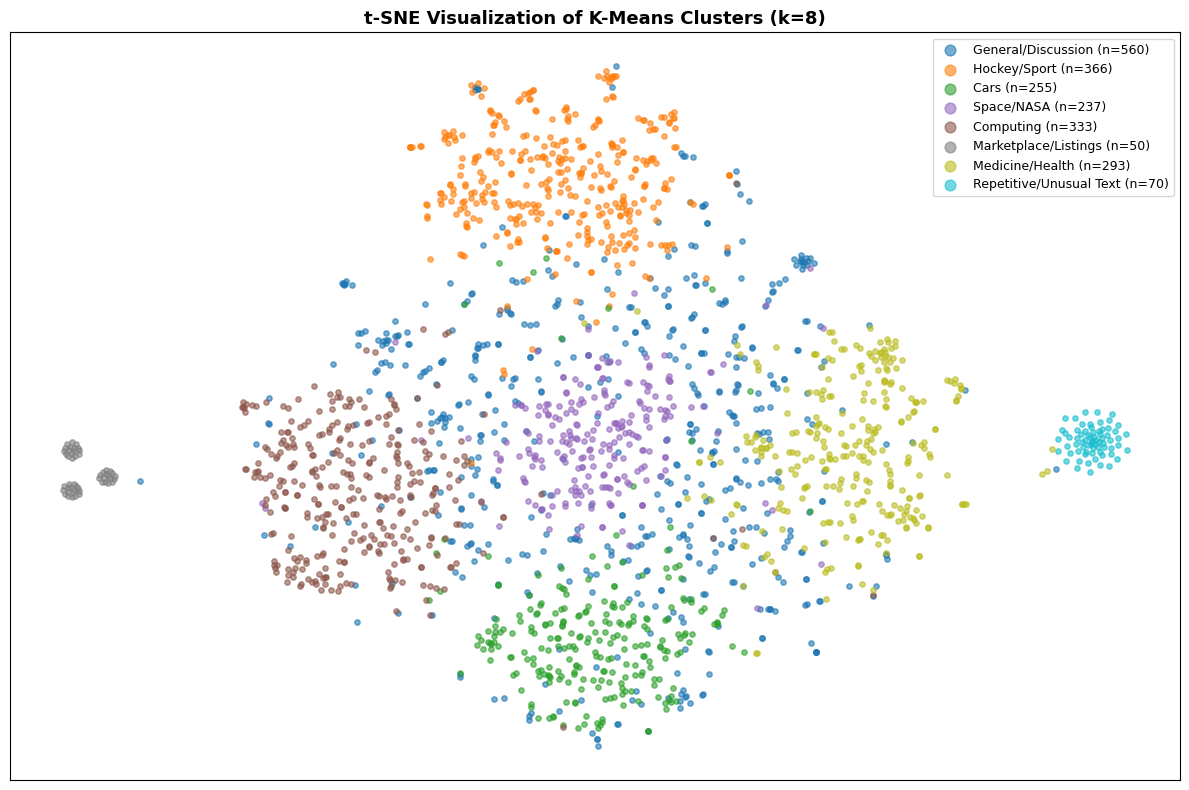

Figure saved


In [26]:

print("Computing t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=40, learning_rate='auto', init='pca')
X_2d = tsne.fit_transform(X_lsa)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.tab10(np.linspace(0, 1, 8))

for c, name in cluster_names.items():
    mask = labels_km == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=[colors[c]], label=f'{name} (n={mask.sum()})',
               s=15, alpha=0.6)

ax.set_title('t-SNE Visualization of K-Means Clusters (k=8)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, markerscale=2)
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.savefig(os.path.join(figures, 'tsne_kmeans.png'), dpi=150)
plt.show()
print("Figure saved")

---
### 7. Hierarchical Clustering

In [10]:
# Fit with same K=8 for comparison
hc = AgglomerativeClustering(n_clusters=8, linkage='ward')
labels_hc = hc.fit_predict(X_lsa)

article['cluster_hc'] = labels_hc

# Silhouette score
from sklearn.metrics import silhouette_score
sil_hc = silhouette_score(X_lsa, labels_hc)
print(f"Hierarchical silhouette score: {sil_hc:.4f}")

# Cluster sizes
print("\nCluster sizes:")
print(pd.Series(labels_hc).value_counts().sort_index())

Hierarchical silhouette score: 0.0470

Cluster sizes:
0    901
1     33
2    372
3     71
4    480
5    261
6     29
7     17
Name: count, dtype: int64


In [11]:
print("=== Hierarchical Top Terms per Cluster ===\n")
top_terms_per_cluster(X, labels_hc, feature_names)

=== Hierarchical Top Terms per Cluster ===

Cluster 0 (901 docs): ['space', 'people', 'time', 'make', 'years', 'good', 'does', 'long', 'new', 'way']
Cluster 1 (33 docs): ['ref', 'promo', 'listing', 'id', 'sale', 'code', 'listing id', 'bundle', 'price', 'price ref']
Cluster 2 (372 docs): ['game', 'team', 'hockey', 'play', 'players', 'games', 'season', 'nhl', 'league', 'teams']
Cluster 3 (71 docs): ['shameful surrender', 'surrender soon', 'intellect shameful', 'shameful', 'skepticism chastity', 'banks jxp', 'jxp', 'jxp skepticism', 'chastity intellect', 'chastity']
Cluster 4 (480 docs): ['thanks', 'graphics', 'files', 'program', 'software', 'help', 'image', 'does', 'looking', 'information']
Cluster 5 (261 docs): ['car', 'cars', 'engine', 'dealer', 'ford', 'price', 'good', 'new', 'drive', 'oil']
Cluster 6 (29 docs): ['msg', 'food', 'chinese', 'restaurant', 'flavor', 'foods', 'chinese food', 'chinese restaurant', 'taste', 'glutamate']
Cluster 7 (17 docs): ['pickup', 'cash cash', 'discount'

---
### 8. Dendrogram

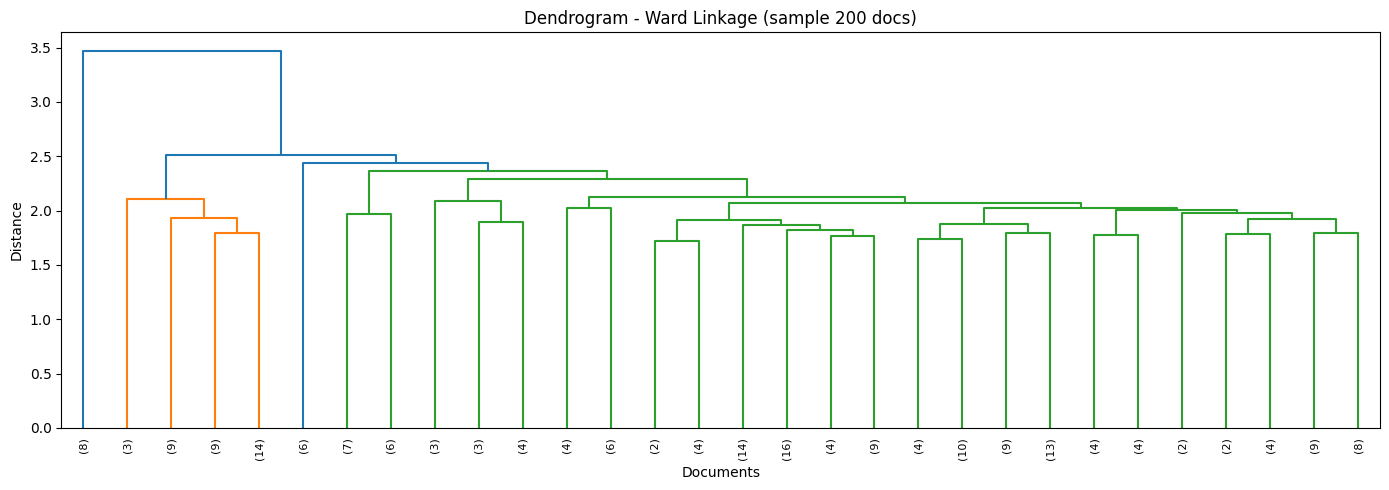

Figure saved


In [12]:
np.random.seed(42)
sample_idx = np.random.choice(len(X_lsa), 200, replace=False)
Z = linkage(X_lsa[sample_idx], method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=8)
ax.set_title('Dendrogram - Ward Linkage (sample 200 docs)')
ax.set_xlabel('Documents')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.savefig(os.path.join(figures, 'dendrogram.png'), dpi=150)
plt.show()
print("Figure saved")

---
### 9. Spectral Clustering

In [13]:


sc = SpectralClustering(n_clusters=8, random_state=42, 
                        affinity='rbf', assign_labels='kmeans', 
                        n_init=10)
labels_sc = sc.fit_predict(X_lsa)

article['cluster_sc'] = labels_sc

# Silhouette score
sil_sc = silhouette_score(X_lsa, labels_sc)
print(f"Spectral silhouette score: {sil_sc:.4f}")

# Cluster sizes
print("\nCluster sizes:")
print(pd.Series(labels_sc).value_counts().sort_index())

Spectral silhouette score: 0.0554

Cluster sizes:
0    448
1    919
2    386
3     17
4     16
5     70
6     17
7    291
Name: count, dtype: int64


In [14]:

print("=== Spectral Top Terms per Cluster ===\n")
top_terms_per_cluster(X, labels_sc, feature_names)

=== Spectral Top Terms per Cluster ===

Cluster 0 (448 docs): ['thanks', 'graphics', 'files', 'program', 'does', 'help', 'looking', 'image', 'file', 'mail']
Cluster 1 (919 docs): ['space', 'people', 'time', 'years', 'use', 'make', 'good', 'work', 'long', 'way']
Cluster 2 (386 docs): ['game', 'team', 'hockey', 'play', 'players', 'games', 'season', 'nhl', 'teams', 'league']
Cluster 3 (17 docs): ['pickup', 'cash cash', 'discount', 'pickup pickup', 'cash', 'quick pickup', 'pickup quick', 'special discount', 'discount special', 'limited']
Cluster 4 (16 docs): ['bonus', 'click', 'item', 'listing', 'promo', 'offer', 'sale', 'ref', 'deal', 'button']
Cluster 5 (70 docs): ['surrender soon', 'intellect shameful', 'shameful', 'shameful surrender', 'chastity intellect', 'skepticism chastity', 'banks jxp', 'chastity', 'jxp skepticism', 'jxp']
Cluster 6 (17 docs): ['ref', 'id', 'promo', 'listing id', 'listing', 'code', 'price ref', 'sale', 'sale code', 'coupon']
Cluster 7 (291 docs): ['car', 'cars', 

---
### 10. Comparison of the three clustering models

In [15]:
print("=" * 50)
print("CLUSTERING METHODS COMPARISON")
print("=" * 50)

sil_km = silhouette_score(X_lsa, labels_km)

print(f"\n{'Method':<25} {'Silhouette':>12} {'Observation'}")
print("-" * 70)
print(f"{'K-Means (k=8)':<25} {sil_km:>12.4f}  Clean clusters, anomalies well grouped")
print(f"{'Hierarchical (k=8)':<25} {sil_hc:>12.4f}  Found food/chinese subcategory")
print(f"{'Spectral (k=8)':<25} {sil_sc:>12.4f}  Best score but splits anomalies")

print("\nBest method: K-Means → cleanest thematic clusters")

CLUSTERING METHODS COMPARISON

Method                      Silhouette Observation
----------------------------------------------------------------------
K-Means (k=8)                   0.0504  Clean clusters, anomalies well grouped
Hierarchical (k=8)              0.0470  Found food/chinese subcategory
Spectral (k=8)                  0.0554  Best score but splits anomalies

Best method: K-Means → cleanest thematic clusters


---
### 11. Saves cluster.csv

In [29]:
output = pd.DataFrame({
    'doc_id': article['doc_id'],
    'cluster': labels_km,
    'cluster_name': article['cluster_name']
})

final_path = os.path.join(path, 'final_output')

os.makedirs(final_path, exist_ok=True)

output.to_csv(os.path.join(final_path, 'clusters.csv'), index=False)

print("clusters.csv saved")

clusters.csv saved
